<a href="https://colab.research.google.com/github/dev-yooillog/MAIN_QUEST/blob/main/Mini_Project4/Salary_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Salary Data.csv'
salary = pd.read_csv(file_path)

In [4]:
salary.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [6]:
salary.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [7]:
salary = salary.dropna()

### 중복 데이터 삭제

In [8]:
len(salary)

373

In [9]:
salary = salary.drop_duplicates()

In [10]:
len(salary)

324

### 이상치

In [11]:
error_count = len(salary[salary['Age'] < salary['Years of Experience']])

In [12]:
salary = salary[salary['Age'] >= salary['Years of Experience']]

In [13]:
salary = salary[salary['Years of Experience'] >= 0]

### Data Transformation

In [14]:
salary['log_salary'] = np.log1p(salary['Salary'])

### 범주형 데이터 인코딩

In [15]:
le = LabelEncoder()
salary['Gender_Enc'] = le.fit_transform(salary['Gender'])
salary['Edu_Enc'] = le.fit_transform(salary['Education Level'])

In [16]:
salary[['Gender', 'Gender_Enc', 'Education Level', 'Edu_Enc']].head()

,Gender,Gender_Enc,Education Level,Edu_Enc
0,Male,1,Bachelor's,0
1,Female,0,Master's,1
2,Male,1,PhD,2
3,Female,0,Bachelor's,0
4,Male,1,Master's,1


### 스케일링

In [17]:
scaler = StandardScaler()

In [18]:
salary[['Age_Scaled', 'Exp_Scaled']] = scaler.fit_transform(salary[['Age', 'Years of Experience']])

### 주성분 분석

In [19]:
pca = PCA(n_components=2)

In [20]:
features = salary[['Age_Scaled', 'Exp_Scaled', 'Gender_Enc', 'Edu_Enc']]

In [21]:
pca_result = pca.fit_transform(features)

In [22]:
salary['PC1'] = pca_result[:, 0]
salary['PC2'] = pca_result[:, 1]

In [23]:
pca.explained_variance_ratio_.sum()

np.float64(0.9024593301268979)

### EDA

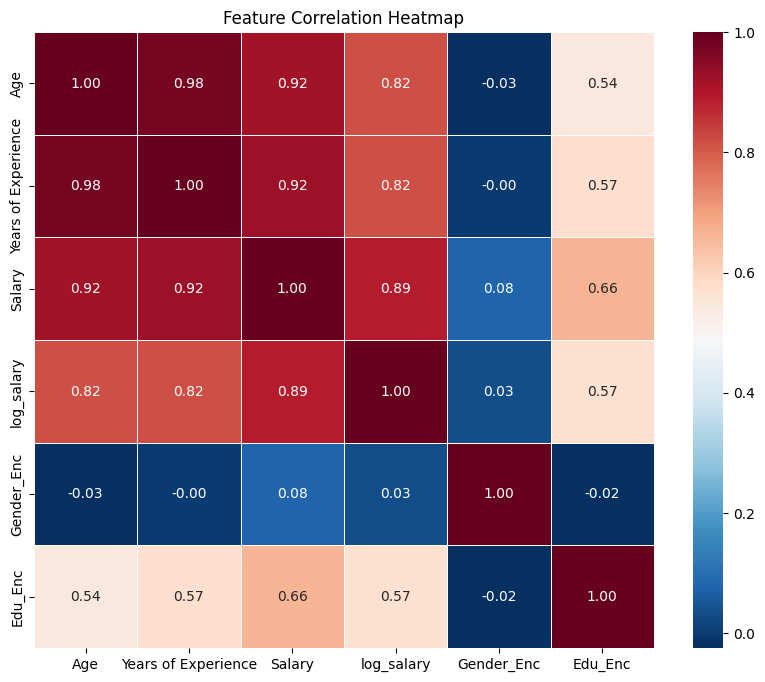

In [24]:
plt.figure(figsize=(10, 8))
correlation_matrix = salary[['Age', 'Years of Experience', 'Salary', 'log_salary', 'Gender_Enc', 'Edu_Enc']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

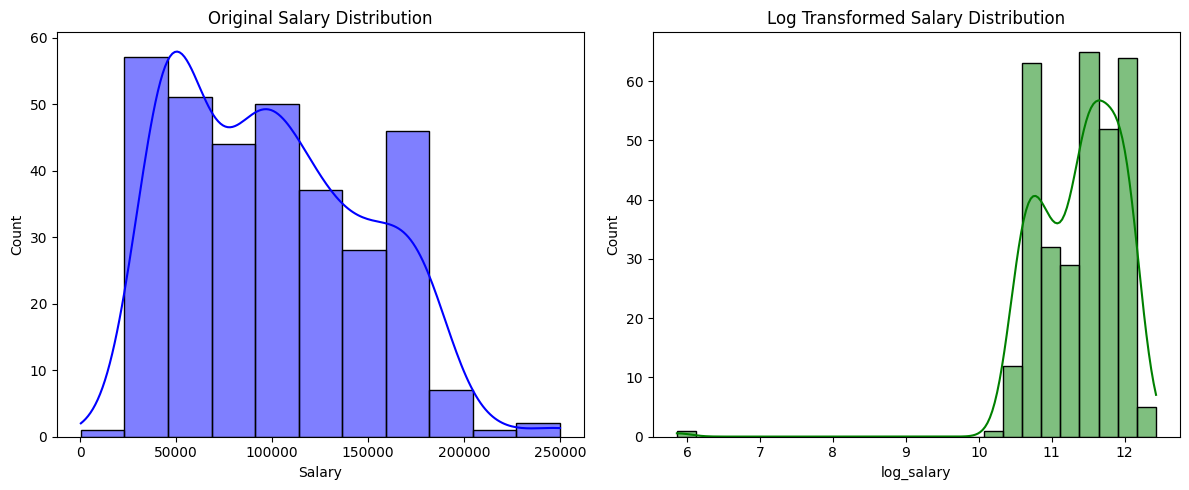

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(salary['Salary'], kde=True, color='blue')
plt.title('Original Salary Distribution')

plt.subplot(1, 2, 2)
sns.histplot(salary['log_salary'], kde=True, color='green')
plt.title('Log Transformed Salary Distribution')

plt.tight_layout()
plt.show()

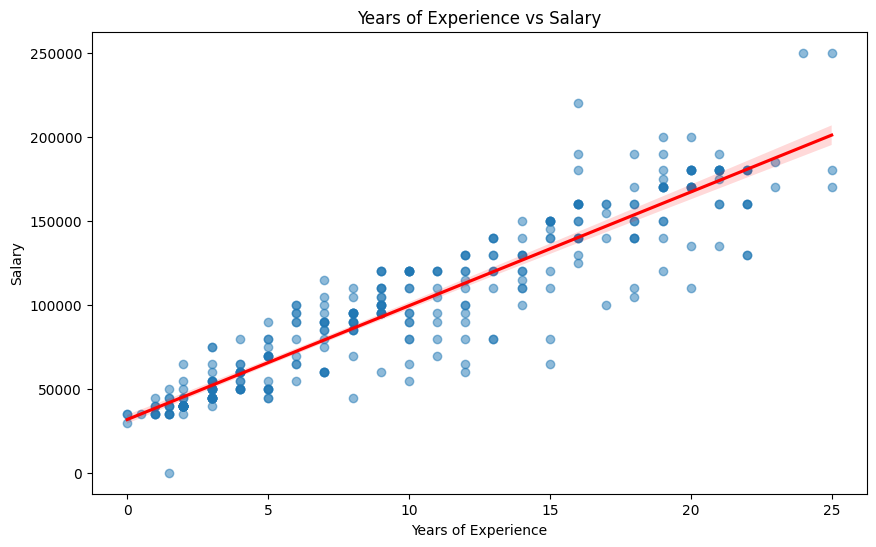

In [26]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Years of Experience', y='Salary', data=salary,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [27]:
salary.describe()

,Age,Years of Experience,Salary,log_salary,Gender_Enc,Edu_Enc,Age_Scaled,Exp_Scaled,PC1,PC2
count,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,3.240000e+02,3.240000e+02,3.240000e+02,3.240000e+02
mean,37.382716,10.058642,99985.648148,11.371745,0.524691,0.540123,1.398059e-16,-6.579099e-17,5.756712e-17,1.151342e-16
std,7.185844,6.650470,48652.271440,0.603921,0.500162,0.713597,1.001547e+00,1.001547e+00,1.475027e+00,5.657877e-01
min,23.000000,0.000000,350.000000,5.860786,0.000000,0.000000,-2.004631e+00,-1.514810e+00,-2.475886e+00,-1.430242e+00
25%,31.000000,4.000000,55000.000000,10.915107,0.000000,0.000000,-8.896086e-01,-9.124188e-01,-1.356861e+00,-3.680418e-01
50%,36.500000,9.000000,95000.000000,11.461643,1.000000,0.000000,-1.230310e-01,-1.594293e-01,-2.193615e-01,-6.330320e-02
75%,44.000000,16.000000,140000.000000,11.849405,1.000000,1.000000,9.223021e-01,8.947560e-01,1.460670e+00,3.205682e-01
max,53.000000,25.000000,250000.000000,12.429220,1.000000,2.000000,2.176702e+00,2.250137e+00,3.235805e+00,1.368568e+00


In [28]:
output_path = '/content/drive/MyDrive/Colab Notebooks/Salary_Data_Cleaned.csv'
salary.to_csv(output_path, index=False)